<a href="https://colab.research.google.com/github/Vanisha-18/AIML_Projects-Labs/blob/main/Copy_of_AIML_Module_5_Lab_2_Loss_Functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Regression Lab 2: Loss Functions


## Motivation

The main goal of machine learning tasks is to "learn" something about data we feed to our models. But how does the model actually learn anything? To understand this, we need to first understand what objective functions are.

Mathematically, objective functions are a function whose values we desire to minimize/maximize. In the context of machine learning, the objective is commonly referred to as a **loss function**. Loss functions indicate how well the model is doing on the dataset.

The value of the objective function is simply called **loss**. Our goal is to eventually find the best model parameters that has the least average loss on the data after training.


We are familiar with the idea of **error** from the linear regression lab. RMSE is a common loss function used in machine learning. However, there are many other loss functions employed, depending on what the task is (classification, regression etc.). In this lab, we will take a look at some common loss functions, and understand why they are used where they are.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# interactive visualization

# 1. Regression


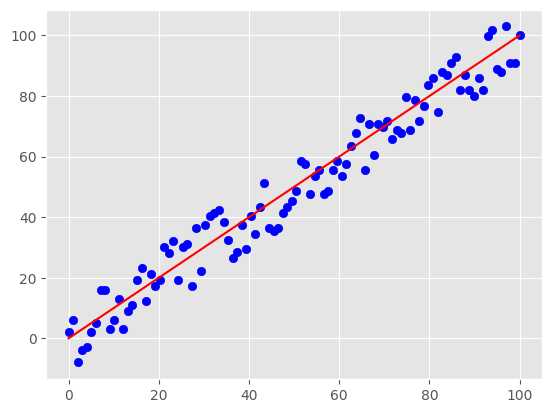

In [2]:
# initializing random data

np.random.seed(0)
x = np.linspace(0,100,100)
y_actual = np.copy(x)
y_pred = x + np.random.randint(-10,10,100)

plt.plot(x,y_actual,color="red")
plt.scatter(x,y_pred,color="blue")
plt.show()

### Mean Squared Error

As we have seen before, the formula for MSE is

$MSE = \frac{1}{m} \sum_{i=1}^n (y-y_p)^2$

The image below depicts a visualization of what the squared error is.

<img src="https://drive.google.com/uc?export=view&id=12jmqRrrqknIWKhwRpgRIJAErBjkEcyx9" width="350" height="350" align="middle"/>

MSE is also referred to as L2 loss.

Typically, we would want the units of error to be the same as the data, so we use Root Mean Squared Error instead.



In [3]:
mse = np.mean((y_actual-y_pred)**2)
print("MSE is: {}".format(mse))
print("RMSE is: {}".format(np.sqrt(mse)))

MSE is: 38.68
RMSE is: 6.219324722186485


### Mean Absolute Error

$MAE = \frac{1}{m} \sum_{i=1}^n |y-y_p|$

MAE is also commonly referred to as L1 loss.

In [4]:
mae = np.mean(np.abs(y_actual-y_pred))
print("MAE is: {}".format(mae))

MAE is: 5.5


MSE penalizes the model for making large errors by squaring the difference. However, this also means that MSE cannot handle outliers well, since they would throw the model off.

On the other hand, MAE is robust to outliers. But, MAE is non-differentiable, making it difficult to perform mathematical operations on it.

Hence, RMSE is most commonly used as a metric for evaluation.

# 2. Classification

Classification tasks involve some data, along with labels assigned to that data. For example, we may have pictures of cats and dogs, and the corresponding labels assigned to those images. We then want to train a model that can predict a label for some input image belonging to either label class (cat or dog).

## The concept of maximum likelihood

Ideally, we would want to obtain a model $\hat{\theta}$ which maximizes the probability of correctly predicting data. Mathematically, the likelihood is:

$ \prod_{i=1}^{N}  \: \hat{\theta_i}^{\theta_i}$

This is because our actual data ($\theta_i$) is either 0 or 1 depending on the label of the data, and our predicted data ($\hat{\theta_i}$) is a probability.

We usually consider the negative log of the likelihood, since log is monotonic and easier to deal with as an optimization problem.

Hence, we have

$MLE = $ arg min $\: - \sum_{i=1}^{N} \theta_i \: log \: \hat{\theta_i}$

\


## Entropy and Cross-Entropy

For some event $x$, we can obtain **information** based on its probability distribution. For example, for some event that occurs with $p=1$, we gain no information. Now, if we flip a coin and see that we obtained heads, we say that we got 1 bit of information.

Thus, the information $I$ of some event $x$ is:

$I = -log_2 \: p(x)$

We say that events with a low probability of occuring give high information, and those with a low probability give low information.

Now, if we have some random variable $X$, its **entropy** is the expected value of the information obtained.

$H(x) = - \sum_{k} p_k \: log \: p_k$

Now, suppose we are trying to correctly predict labels of some data. Let P be the true distribution of the labels, and Q be the predicted distribution of labels.

Cross-Entropy is then defined as:

$H(P,Q) = - \sum_{x} P(x)\: log \: Q(x)$

which is basically the entropy between two probability distributions over the same events.

\


## MLE and Cross-Entropy

So, in the case of classification, the equation for minimization of the cross-entropy between the actual data and the predicted data would be:

arg min $\: -\sum_{i=1}^{N} P(x) \: log \: Q(x)$

$= $ arg min $\: -\sum_{i=1}^{N} \theta_i \: log \: \hat{\theta_i}$


which is exactly the same as what we had obtained for minimizing the negative log likelihood. Hence, the two problems are equivalent.

1/1+e^(-x)

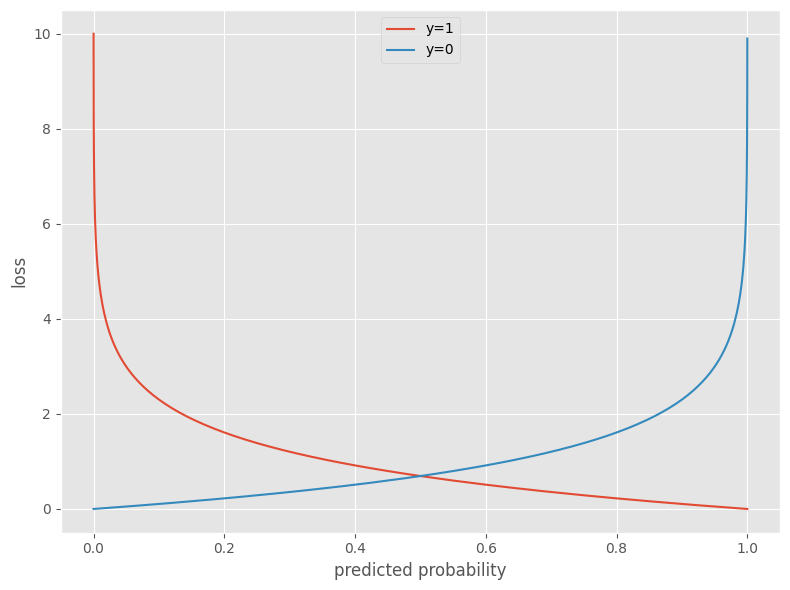

In [5]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

def cross_entropy_loss(y_,y):
  if y==1:
    return -np.log(y_)

  return -np.log(1-y_)

z = np.arange(-10, 10, 0.1)
h_z = sigmoid(z)

cost_1 = cross_entropy_loss(h_z, 1)
cost_0 = cross_entropy_loss(h_z, 0)

fig, ax = plt.subplots(figsize=(8,6))
plt.plot(h_z, cost_1, label='y=1')
plt.plot(h_z, cost_0, label='y=0')
plt.xlabel('predicted probability')
plt.ylabel('loss')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## KNN-regression

Till now, we have studied KNN as a classification algorithm, which uses feature similarity and voting to decide the class labels of unseen data.

For regression, we use the same idea: We take the y-values of the k nearest neighbours, and compute their average, which is our predicted y-value. We do this for every x whose value we want to predict.

In the visualization below, we have k=3, and the red dots are the new x-values whose output we want to predict.

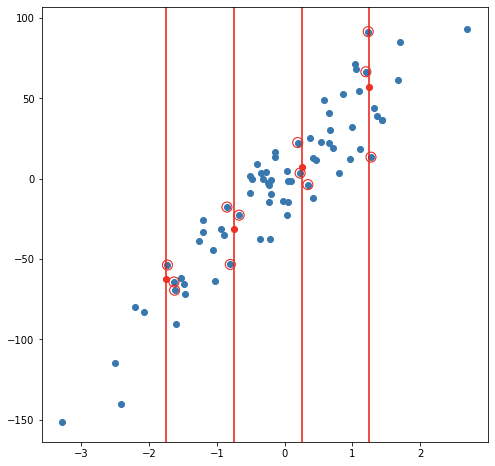

In [6]:
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

In [7]:
train_path = "https://raw.githubusercontent.com/PranavTadimeti/Regression-lab2/main/BigMart-train.csv"

train = pd.read_csv(train_path)

In [8]:
# Preprocess Data

def preprocess(df):
  mean_weight = df['Item_Weight'].mean()
  df['Item_Weight'].fillna(mean_weight,inplace=True)

  mode_size = df['Outlet_Size'].mode()
  df['Outlet_Size'].fillna(mode_size,inplace=True)

  df.drop(['Item_Identifier','Outlet_Identifier'],axis=1,inplace=True)

  return pd.get_dummies(df)

train = preprocess(train)

train.head()

/tmp/ipykernel_13853/319556835.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Weight'].fillna(mean_weight,inplace=True)
/tmp/ipykernel_13853/319556835.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,False,True,False,False,False,...,False,True,False,True,False,False,False,True,False,False
1,5.92,0.019278,48.2692,2009,443.4228,False,False,True,False,False,...,False,True,False,False,False,True,False,False,True,False
2,17.50,0.016760,141.6180,1999,2097.2700,False,True,False,False,False,...,False,True,False,True,False,False,False,True,False,False
3,19.20,0.000000,182.0950,1998,732.3800,False,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
4,8.93,0.000000,53.8614,1987,994.7052,False,True,False,False,False,...,True,False,False,False,False,True,False,True,False,False


In [9]:
train , test = train_test_split(train, test_size = 0.3)

x_train = train.drop('Item_Outlet_Sales', axis=1)
y_train = train['Item_Outlet_Sales']

x_test = test.drop('Item_Outlet_Sales', axis = 1)
y_test = test['Item_Outlet_Sales']

In [10]:
scaler = MinMaxScaler(feature_range=(0, 1))

x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled)

x_test_scaled = scaler.fit_transform(x_test)
x_test = pd.DataFrame(x_test_scaled)

In [11]:
def knn_regression(k,x_train,y_train,x_test,y_test):
    model = neighbors.KNeighborsRegressor(n_neighbors = k)

    model.fit(x_train, y_train)
    pred=model.predict(x_test)
    error = sqrt(mean_squared_error(y_test,pred))
    rmse_val.append(error)

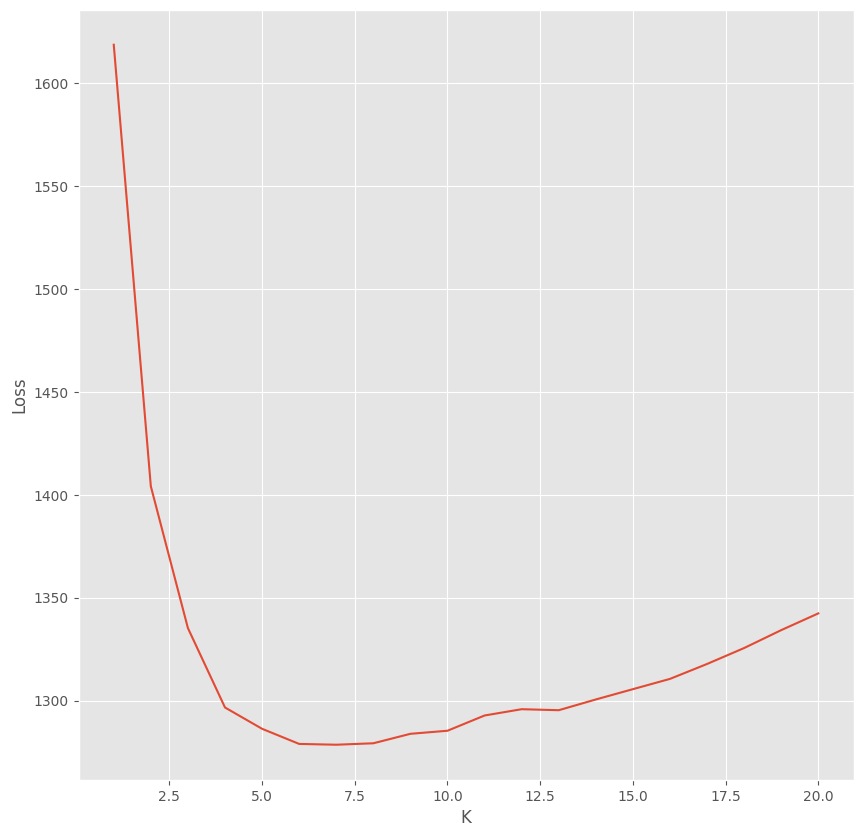

Minimum error 1278.5816281094171 is at k = 6


In [12]:
rmse_val = []

for k in range(1,21):
  knn_regression(k,x_train,y_train,x_test,y_test)

figure = plt.figure(figsize=(10,10))
plt.plot(np.arange(1,21),rmse_val)
plt.xlabel("K")
plt.ylabel("Loss")
plt.show()

rmse_val = np.asarray(rmse_val)
print("Minimum error {} is at k = {}".format(np.min(rmse_val),np.argmin(rmse_val)))

## Exercises

1. Try out these loss functions on regression tasks, and try to understand the model performance based on the loss function.
2. Explore other loss functions and try to understand when and why they are used.
3. Try out KNN-regression on other datasets see which values of K give the best results.
4. Try exploring what will happen if K is set to 1 or K is set to size of whole training dataset.

### Exercise 1: Comparing MSE and MAE on regression with outliers

We already computed MSE/RMSE and MAE on the synthetic dataset above. Here we add an **outlier** to see how each loss reacts differently.

Without outlier -> MSE: 38.68, MAE: 5.50
With outlier    -> MSE: 2518.68, MAE: 10.46

MSE increased by factor: 65.12
MAE increased by factor: 1.90


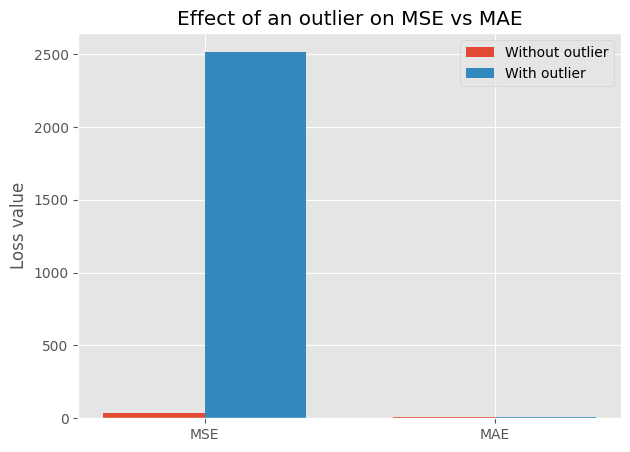

In [19]:
# Add a single large outlier to y_pred and see how MSE vs MAE respond
y_pred_outlier = np.copy(y_pred).astype(float)
y_pred_outlier[50] += 500   # inject one huge outlier

mse_clean = np.mean((y_actual - y_pred) ** 2)
mse_outlier = np.mean((y_actual - y_pred_outlier) ** 2)

mae_clean = np.mean(np.abs(y_actual - y_pred))
mae_outlier = np.mean(np.abs(y_actual - y_pred_outlier))

print("Without outlier -> MSE: {:.2f}, MAE: {:.2f}".format(mse_clean, mae_clean))
print("With outlier    -> MSE: {:.2f}, MAE: {:.2f}".format(mse_outlier, mae_outlier))

print("\nMSE increased by factor: {:.2f}".format(mse_outlier / mse_clean))
print("MAE increased by factor: {:.2f}".format(mae_outlier / mae_clean))

# Bar chart comparing MSE and MAE, with and without the outlier
labels = ['MSE', 'MAE']
clean_vals = [mse_clean, mae_clean]
outlier_vals = [mse_outlier, mae_outlier]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, clean_vals, width, label='Without outlier')
ax.bar(x + width/2, outlier_vals, width, label='With outlier')

ax.set_ylabel('Loss value')
ax.set_title('Effect of an outlier on MSE vs MAE')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.show()

**Observation:** Adding just one large outlier increases MSE far more drastically than it increases MAE (because MSE squares the error, so a single bad prediction dominates the average). MAE grows only linearly with the outlier's size, which is why MAE is considered more *robust to outliers*, while MSE is more sensitive to them. This confirms the explanation given in the notebook.

### Exercise 2: Exploring another loss function — Huber Loss

Huber loss combines MSE and MAE: it behaves like MSE for small errors (smooth, differentiable) and like MAE for large errors (robust to outliers). It is controlled by a threshold parameter `delta`.

$$
L_\delta(y, y_p) =
\begin{cases}
\frac{1}{2}(y-y_p)^2 & |y-y_p| \le \delta \\
\delta \cdot (|y-y_p| - \frac{1}{2}\delta) & \text{otherwise}
\end{cases}
$$

Huber loss without outlier: 19.34
Huber loss with outlier:    68.62


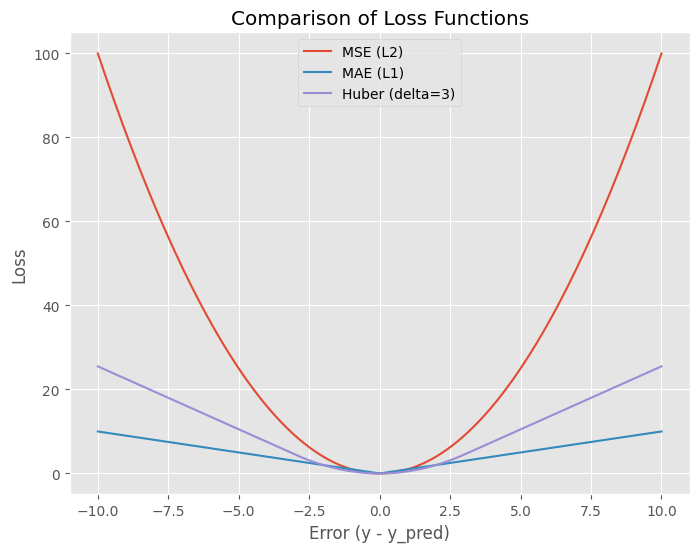

In [18]:
def huber_loss(y, y_p, delta=1.0):
    error = y - y_p
    abs_error = np.abs(error)
    quadratic = np.minimum(abs_error, delta)
    linear = abs_error - quadratic
    return np.mean(0.5 * quadratic**2 + delta * linear)

huber_clean = huber_loss(y_actual, y_pred, delta=10)
huber_outlier = huber_loss(y_actual, y_pred_outlier, delta=10)

print("Huber loss without outlier: {:.2f}".format(huber_clean))
print("Huber loss with outlier:    {:.2f}".format(huber_outlier))

# Plot MSE, MAE, and Huber loss as a function of error magnitude
errors = np.linspace(-10, 10, 200)

mse_curve = errors**2
mae_curve = np.abs(errors)
delta = 3
huber_curve = np.where(np.abs(errors) <= delta,
                        0.5 * errors**2,
                        delta * (np.abs(errors) - 0.5 * delta))

plt.figure(figsize=(8, 6))
plt.plot(errors, mse_curve, label='MSE (L2)')
plt.plot(errors, mae_curve, label='MAE (L1)')
plt.plot(errors, huber_curve, label='Huber (delta=3)')
plt.xlabel('Error (y - y_pred)')
plt.ylabel('Loss')
plt.title('Comparison of Loss Functions')
plt.legend()
plt.show()

**Observation:** The plot shows MSE growing quadratically (steepest for large errors), MAE growing linearly throughout, and Huber loss following MSE's smooth curve near zero but switching to MAE's linear growth beyond `delta=3`. This visually confirms why Huber loss is a "best of both worlds" compromise — smooth/differentiable near zero, robust to large outliers far from zero.

### Exercise 3: KNN Regression on another dataset (sklearn's Diabetes dataset)

We repeat the KNN-regression experiment on a different dataset to see which k minimizes RMSE there.

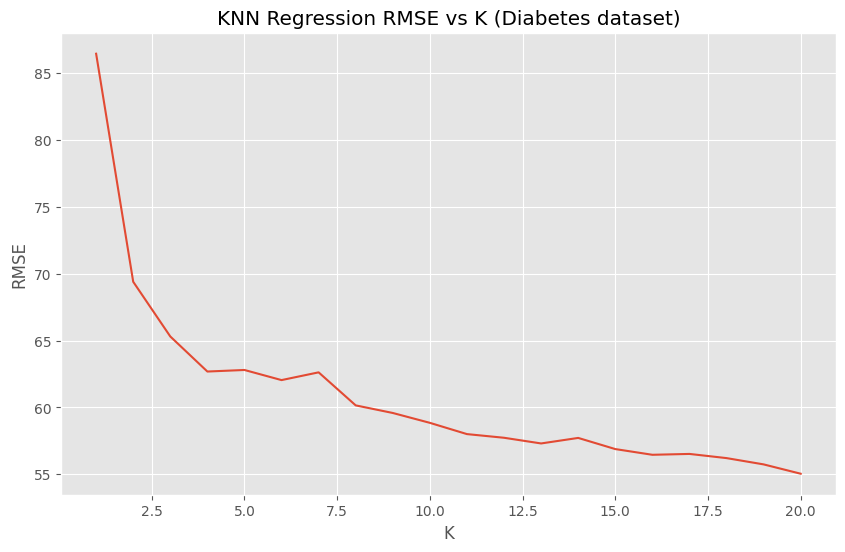

Minimum error 55.05 is at k = 20


In [15]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.3, random_state=0)

scaler2 = MinMaxScaler(feature_range=(0, 1))
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)   # use transform, not fit_transform, on test set

rmse_val2 = []
for k in range(1, 21):
    model = neighbors.KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train2_scaled, y_train2)
    pred = model.predict(X_test2_scaled)
    rmse_val2.append(sqrt(mean_squared_error(y_test2, pred)))

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, 21), rmse_val2)
plt.xlabel("K")
plt.ylabel("RMSE")
plt.title("KNN Regression RMSE vs K (Diabetes dataset)")
plt.show()

rmse_val2 = np.asarray(rmse_val2)
print("Minimum error {:.2f} is at k = {}".format(np.min(rmse_val2), np.argmin(rmse_val2) + 1))

**Observation:** The optimal k differs from the BigMart dataset because it depends on the dataset's size, noise level, and feature scale. Very small k values tend to overfit (low bias, high variance), while large k values tend to underfit (high bias, low variance) — the RMSE curve typically dips at some moderate k before rising again, similar to the BigMart result.

### Exercise 4: Effect of k = 1 vs k = size of training set

- **k = 1**: the prediction is just the y-value of the single nearest neighbor — extremely sensitive to noise, low bias but very high variance (overfitting).
- **k = N** (all training points): the prediction is the same constant value (the mean of all training y-values) for every test point — high bias, zero variance (severe underfitting).

RMSE at k=1: 1618.57
RMSE at k=5966 (= train set size): 1791.13
Predicted values are identical for all test points at k=N: True


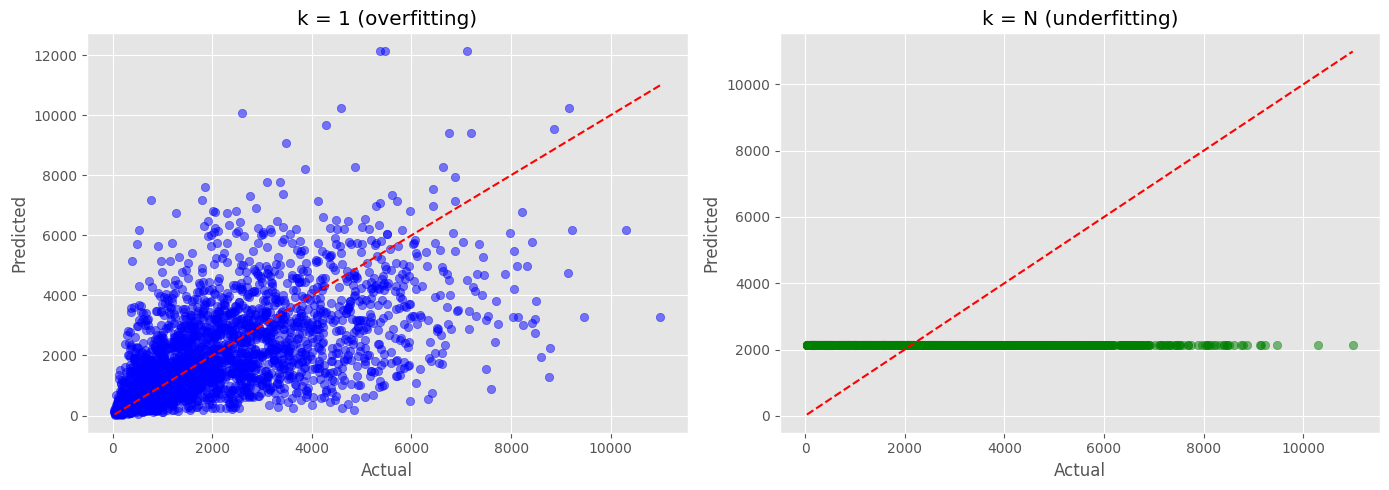

In [20]:
# k = 1 (BigMart data, already preprocessed earlier in the notebook)
knn_k1 = neighbors.KNeighborsRegressor(n_neighbors=1)
knn_k1.fit(x_train, y_train)
pred_k1 = knn_k1.predict(x_test)
rmse_k1 = sqrt(mean_squared_error(y_test, pred_k1))

# k = size of training set
n_train = len(x_train)
knn_kn = neighbors.KNeighborsRegressor(n_neighbors=n_train)
knn_kn.fit(x_train, y_train)
pred_kn = knn_kn.predict(x_test)
rmse_kn = sqrt(mean_squared_error(y_test, pred_kn))

print("RMSE at k=1: {:.2f}".format(rmse_k1))
print("RMSE at k={} (= train set size): {:.2f}".format(n_train, rmse_kn))
print("Predicted values are identical for all test points at k=N:", np.allclose(pred_kn, pred_kn[0]))

# Visualize predictions vs actual values for k=1 vs k=N
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, pred_k1, alpha=0.5, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('k = 1 (overfitting)')

axes[1].scatter(y_test, pred_kn, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('k = N (underfitting)')

plt.tight_layout()
plt.show()

**Observation:** In the k=1 scatter plot, predictions are scattered noisily around the ideal red diagonal line (high variance from relying on single neighbors). In the k=N plot, all predicted points fall on a single horizontal line (the constant mean prediction), clearly visualizing the total loss of input-dependence — the model has completely underfit the data.

## References ##
1. https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html
2. https://www.geeksforgeeks.org/k-nearest-neighbours/
3. https://bookdown.org/tpinto_home/Regression-and-Classification/k-nearest-neighbours-regression.html#:~:text=KNN%20regression%20is%20a%20non,observations%20in%20the%20same%20neighbourhood